# Proyek Analisis Data: E-Commerce Public Dataset

## Menentukan Pertanyaan Bisnis

### Pertanyaan 1 (SMART)

**"Kategori produk apa saja yang menghasilkan total pendapatan tertinggi dan memiliki tingkat pembatalan order terbesar selama periode Januari 2017 hingga Desember 2018?"**

**Keterangan SMART:**

- **Specific**: Fokus pada kategori produk, total pendapatan, dan tingkat pembatalan order
- **Measurable**: Dapat diukur dalam angka (R$) dan persentase (%)
- **Action-Oriented**: Hasilnya menunjukkan kategori mana yang perlu diperbaiki proses fulfillment-nya
- **Relevant**: Pendapatan dan pembatalan adalah metrik kritis dalam bisnis e-commerce
- **Time-bound**: Periode Januari 2017 – Desember 2018

---

### Pertanyaan 2 (SMART)

**"Bagaimana distribusi RFM (Recency, Frequency, Monetary) pelanggan berdasarkan transaksi 12 bulan terakhir dataset, dan berapa persen pelanggan yang termasuk segmen Champions dibandingkan segmen At Risk?"**

**Keterangan SMART:**

- **Specific**: Fokus pada distribusi RFM dan perbandingan segmen Champions vs At Risk
- **Measurable**: Dapat dihitung dalam persentase dan skor RFM (1-5)
- **Action-Oriented**: Menentukan strategi retensi pelanggan yang tepat per segmen
- **Relevant**: RFM adalah metrik standar untuk retensi pelanggan di e-commerce
- **Time-bound**: 12 bulan terakhir dataset

In [17]:
# ============================================================
# 1. GATHERING DATA (Mengumpulkan Data)
# ============================================================
# Tujuan: Memuat semua file CSV ke dalam DataFrame

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Memuat semua dataset ---
customers_df       = pd.read_csv('data/customers_dataset.csv')
geolocation_df     = pd.read_csv('data/geolocation_dataset.csv')
order_items_df     = pd.read_csv('data/order_items_dataset.csv')
payments_df        = pd.read_csv('data/order_payments_dataset.csv')
reviews_df         = pd.read_csv('data/order_reviews_dataset.csv')
orders_df          = pd.read_csv('data/orders_dataset.csv')
category_df        = pd.read_csv('data/product_category_name_translation.csv')
products_df        = pd.read_csv('data/products_dataset.csv')
sellers_df         = pd.read_csv('data/sellers_dataset.csv')

# --- Melihat ringkasan masing-masing dataset ---
datasets = {
    'customers'   : customers_df,
    'geolocation' : geolocation_df,
    'order_items' : order_items_df,
    'payments'    : payments_df,
    'reviews'     : reviews_df,
    'orders'      : orders_df,
    'category'    : category_df,
    'products'    : products_df,
    'sellers'     : sellers_df
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"Dataset: {name} | Baris: {df.shape[0]} | Kolom: {df.shape[1]}")
    print(df.head(3))


Dataset: customers | Baris: 99441 | Kolom: 5
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  

Dataset: geolocation | Baris: 1000163 | Kolom: 5
   geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                         1037       -23.545621       -46.639292   
1                         1046       -23.546081       -46.644820   
2                         1046       -23.546129       -46.642951   

  geolocation_city geolocation_state  
0        sao paulo         

### Insight: Gathering Data

Dataset E-Commerce terdiri dari 9 file CSV yang saling berkaitan melalui key:
- `customer_id` → menghubungkan orders dengan customers
- `order_id` → menghubungkan orders dengan order_items, payments, reviews
- `product_id` → menghubungkan order_items dengan products

Semua file berhasil dimuat ke dalam DataFrame tanpa error.
Dataset mencakup pesanan dari tahun 2016–2018.

In [18]:
# ============================================================
# 2. ASSESSING DATA (Menilai Kualitas Data)
# ============================================================
# Tujuan: Menemukan MASALAH dalam data

# --- Cek Missing Values ---
print("=" * 60)
print("MISSING VALUES PER DATASET")
print("=" * 60)

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n--- {name} ---")
        print(missing)
    else:
        print(f"\n--- {name} --- Tidak ada missing value")

MISSING VALUES PER DATASET

--- customers --- Tidak ada missing value

--- geolocation --- Tidak ada missing value

--- order_items --- Tidak ada missing value

--- payments --- Tidak ada missing value

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- category --- Tidak ada missing value

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- sellers --- Tidak ada missing value


In [19]:
# --- Cek Duplikat Data ---
print("=" * 60)
print("DUPLIKAT DATA PER DATASET")
print("=" * 60)

for name, df in datasets.items():
    dup = df.duplicated().sum()
    if dup > 0:
        print(f"\n{name}: {dup} baris duplikat")

# --- Cek Tipe Data pada Orders ---
print("\n" + "=" * 60)
print("TIPE DATA PADA orders_dataset")
print("=" * 60)
print(orders_df.dtypes)

DUPLIKAT DATA PER DATASET

geolocation: 261831 baris duplikat

TIPE DATA PADA orders_dataset
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [20]:
# --- Cek Outlier pada Pembayaran ---
print("=" * 60)
print("OUTLIER PADA PEMBAYARAN")
print("=" * 60)

print(payments_df['payment_value'].describe())

Q1 = payments_df['payment_value'].quantile(0.25)
Q3 = payments_df['payment_value'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (payments_df['payment_value'] < Q1 - 1.5*IQR) | \
               (payments_df['payment_value'] > Q3 + 1.5*IQR)

print(f"\nJumlah outlier: {outlier_mask.sum()}")
print(f"Nilai outlier tertinggi: Rp {payments_df.loc[outlier_mask, 'payment_value'].max():,.0f}")

OUTLIER PADA PEMBAYARAN
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Jumlah outlier: 7981
Nilai outlier tertinggi: Rp 13,664


### Masalah yang Ditemukan & Solusi

| No | Masalah | Lokasi | Solusi |
|----|---------|--------|--------|
| 1 | **Missing Values** | `orders_dataset` → kolom `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` | Dibiarkan (karena pesanan cancelled memang tidak punya tanggal kirim) |
| 2 | **Missing Values** | `order_reviews_dataset` → kolom `review_comment_message` | Drop baris yang kosong untuk analisis |
| 3 | **Duplicate Data** | `geolocation_dataset` | Hapus duplikat dengan `.drop_duplicates()` |
| 4 | **Inconsistent Value** | `orders_dataset` → kolom tanggal masih bertipe `object` (string) | Konversi ke `datetime` dengan `pd.to_datetime()` |
| 5 | **Outlier** | `order_payments_dataset` → kolom `payment_value` | Tandai sebagai kolom `is_outlier` (tidak dihapus, karena bisa jadi data valid) |

In [21]:
# ============================================================
# 3. CLEANING DATA (Membersihkan Data)
# ============================================================
# Tujuan: Memperbaiki semua masalah dari tahap Assessing

# --- Solusi 1: Drop duplikat geolocation ---
geolocation_df_clean = geolocation_df.drop_duplicates().reset_index(drop=True)
print(f"Geolocation: {len(geolocation_df)} → {len(geolocation_df_clean)} baris")

# --- Solusi 2: Drop review yang kosong ---
reviews_df_clean = reviews_df.dropna(subset=['review_comment_message'])
print(f"Reviews: {len(reviews_df)} → {len(reviews_df_clean)} baris")

# --- Solusi 3: Konversi tipe data tanggal ---
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

# Tanggal di tabel lain
order_items_df['shipping_limit_date']  = pd.to_datetime(order_items_df['shipping_limit_date'])
reviews_df['review_creation_date']     = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp']  = pd.to_datetime(reviews_df['review_answer_timestamp'])

print("Tipe data tanggal setelah konversi:")
print(orders_df[date_columns].dtypes)

# --- Solusi 4: Tandai outlier (tidak dihapus) ---
Q1 = payments_df['payment_value'].quantile(0.25)
Q3 = payments_df['payment_value'].quantile(0.75)
IQR = Q3 - Q1
payments_df['is_outlier'] = (
    (payments_df['payment_value'] < Q1 - 1.5*IQR) |
    (payments_df['payment_value'] > Q3 + 1.5*IQR)
)
print(f"Outlier ditandai: {payments_df['is_outlier'].sum()} baris")

Geolocation: 1000163 → 738332 baris
Reviews: 99224 → 40977 baris
Tipe data tanggal setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
Outlier ditandai: 7981 baris


In [22]:
# ============================================================
# 3b. GABUNGKAN DATA (Membuat DataFrame Analisis)
# ============================================================
# Menggabungkan beberapa tabel menjadi satu tabel utama

# Gabungkan: orders + order_items + payments + products + category
df_merged = (
    orders_df
    .merge(
        order_items_df,
        on='order_id',
        how='left'
    )
    .merge(
        payments_df.groupby('order_id', as_index=False)['payment_value'].sum(),
        on='order_id',
        how='left'
    )
    .merge(
        products_df[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
    .merge(
        category_df,
        on='product_category_name',
        how='left'
    )
)

# Filter periode Januari 2017 - Desember 2018
df_analysis = df_merged[
    (df_merged['order_purchase_timestamp'] >= '2017-01-01') &
    (df_merged['order_purchase_timestamp'] <= '2018-12-31')
].copy()

print(f"Jumlah baris df_merged: {len(df_merged)}")
print(f"Jumlah baris df_analysis (2017-2018): {len(df_analysis)}")
print(f"\nKolom yang tersedia:")
print(df_analysis.columns.tolist())

Jumlah baris df_merged: 113425
Jumlah baris df_analysis (2017-2018): 113038

Kolom yang tersedia:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_value', 'product_category_name', 'product_category_name_english']


### Insight: Cleaning Data

1. Duplikat geolocation dihapus, menjaga integritas data lokasi.
2. Tanggal dikonversi ke `datetime`, memungkinkan analisis temporal.
3. Outlier ditandai (bukan dihapus) karena bisa jadi data pembelian grosir yang valid.
4. Data berhasil digabung menjadi `df_analysis` berisi pesanan Jan 2017 – Des 2018.
5. Kolom `product_category_name_english` tersedia karena sudah digabung dengan tabel terjemahan.

In [23]:
# ============================================================
# 4. EDA - PERTANYAAN BISNIS 1
# ============================================================
# "Kategori produk apa yang pendapatan tertinggi & pembatalan terbesar?"

# --- 4a. Ringkaman Statistik ---
print("=" * 60)
print("RINGKASAN STATISTIK PEMBAYARAN")
print("=" * 60)
print(df_analysis['payment_value'].describe())

# --- 4b. Total Pendapatan per Kategori (Top 10) ---
print("\n" + "=" * 60)
print("TOP 10 KATEGORI PENDAPATAN TERTINGGI")
print("=" * 60)

revenue_by_cat = (
    df_analysis.groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(revenue_by_cat)

# --- 4c. Tingkat Pembatalan per Kategori (Top 10) ---
print("\n" + "=" * 60)
print("TOP 10 KATEGORI PEMBATALAN TERTINGGI")
print("=" * 60)

cancel_by_cat = (
    df_analysis
    .assign(is_cancelled=df_analysis['order_status'] == 'canceled')
    .groupby('product_category_name_english')['is_cancelled']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'tingkat_pembatalan', 'count': 'total_order'})
    .sort_values('tingkat_pembatalan', ascending=False)
    .head(10)
)
cancel_by_cat['tingkat_pembatalan'] = (cancel_by_cat['tingkat_pembatalan'] * 100).round(2)
print(cancel_by_cat)

# --- 4d. Tren Bulanan Pendapatan ---
print("\n" + "=" * 60)
print("TREN BULANAN PENDAPATAN")
print("=" * 60)

df_analysis['month_year'] = df_analysis['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_revenue = (
    df_analysis.groupby('month_year')['payment_value']
    .sum()
    .reset_index()
)
monthly_revenue.columns = ['Bulan', 'Pendapatan']
print(monthly_revenue.to_string(index=False))

RINGKASAN STATISTIK PEMBAYARAN
count    113038.000000
mean        180.418960
std         273.749465
min           0.000000
25%          65.642500
50%         114.350000
75%         195.130000
max       13664.080000
Name: payment_value, dtype: float64

TOP 10 KATEGORI PENDAPATAN TERTINGGI
product_category_name_english
bed_bath_table           1710261.96
health_beauty            1651310.96
computers_accessories    1582933.75
watches_gifts            1425748.64
furniture_decor          1419051.39
sports_leisure           1388200.45
housewares               1092021.61
auto                      849577.63
garden_tools              836815.56
cool_stuff                778362.59
Name: payment_value, dtype: float64

TOP 10 KATEGORI PEMBATALAN TERTINGGI
                               tingkat_pembatalan  total_order
product_category_name_english                                 
dvds_blu_ray                                 3.12           64
diapers_and_hygiene                          2.63         

In [24]:
# ============================================================
# 4. EDA - PERTANYAAN BISNIS 2 (RFM ANALYSIS)
# ============================================================
# RFM = Recency, Frequency, Monetary
# Tujuan: Mengelompokkan pelanggan berdasarkan perilaku pembelian
#
# - Recency: Berapa hari sejak pembelian terakhir?
# - Frequency: Berapa kali beli?
# - Monetary: Berapa total uang yang dikeluarkan?

# Tanggal referensi = 1 hari setelah transaksi terakhir
snapshot_date = df_merged['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Tanggal Snapshot: {snapshot_date.date()}")

# Filter 12 bulan terakhir
last_12_months = snapshot_date - pd.DateOffset(months=12)
rfm_source = df_merged[df_merged['order_purchase_timestamp'] >= last_12_months].copy()

print(f"Periode RFM: {last_12_months.date()} s/d {snapshot_date.date()}")
print(f"Jumlah transaksi dalam periode: {len(rfm_source)}")

# --- Hitung RFM per pelanggan ---
rfm = rfm_source.groupby('customer_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

print("\n" + "=" * 60)
print("RINGKASAN RFM")
print("=" * 60)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Tanggal Snapshot: 2018-10-18
Periode RFM: 2017-10-18 s/d 2018-10-18
Jumlah transaksi dalam periode: 79007

RINGKASAN RFM
        Recency  Frequency  Monetary
count  69149.00    69149.0  69149.00
mean     206.63        1.0    205.28
std       88.65        0.0    517.05
min        1.00        1.0      0.00
25%      131.00        1.0     62.91
50%      209.00        1.0    111.02
75%      280.00        1.0    196.16
max      364.00        1.0  44048.00


In [25]:
# --- Beri Skor RFM (1-5, 5 = terbaik) ---
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# --- Manual Grouping (Clustering tanpa Machine Learning) ---
def assign_segment(row):
    s = row['RFM_score']
    if s >= 13:
        return 'Champions'
    elif s >= 11:
        return 'Loyal Customers'
    elif s >= 9:
        return 'Potential Loyalist'
    elif s >= 7:
        return 'At Risk'
    else:
        return 'Lost / Hibernating'

rfm['Segmen'] = rfm.apply(assign_segment, axis=1)

# --- Distribusi Segmen ---
print("=" * 60)
print("DISTRIBUSI SEGMEN RFM")
print("=" * 60)

seg_dist = rfm['Segmen'].value_counts()
seg_pct = (rfm['Segmen'].value_counts(normalize=True) * 100).round(1)

for seg in seg_dist.index:
    print(f"  {seg:<20} : {seg_dist[seg]:>5} pelanggan ({seg_pct[seg]}%)")

# Persentase Champions vs At Risk
champions_pct = seg_pct.get('Champions', 0)
at_risk_pct   = seg_pct.get('At Risk', 0)
print(f"\n>>> Champions: {champions_pct}% vs At Risk: {at_risk_pct}%")

DISTRIBUSI SEGMEN RFM
  Potential Loyalist   : 20378 pelanggan (29.5%)
  At Risk              : 17949 pelanggan (26.0%)
  Loyal Customers      : 14061 pelanggan (20.3%)
  Lost / Hibernating   : 11189 pelanggan (16.2%)
  Champions            :  5572 pelanggan (8.1%)

>>> Champions: 8.1% vs At Risk: 26.0%


### Insight: EDA

**Pertanyaan 1 — Pendapatan & Pembatalan:**
- Kategori `bed_bath_table`, `health_beauty`, dan `computers_accessories`
  menghasilkan pendapatan tertinggi.
- Terdapat beberapa kategori dengan tingkat pembatalan di atas rata-rata,
  yang mengindikasikan masalah stok atau proses fulfillment.
- Tren pendapatan bulanan menunjukkan pola musiman dengan puncak di
  akhir tahun (November–Desember).

**Pertanyaan 2 — RFM:**
- Mayoritas pelanggan hanya membeli 1-2 kali (Frequency rendah).
- Segmen `Champions` (skor ≥13) hanya sebagian kecil dari total pelanggan.
- Segmen `At Risk` dan `Lost/Hibernating` mendominasi jumlah pelanggan.
- Hal ini menunjukkan tantangan retensi pelanggan yang signifikan.

In [26]:
# ============================================================
# 5. SIMPAN DATA UNTUK DASHBOARD
# ============================================================
# Membuat file main_data.csv yang akan dibaca oleh dashboard.py

# Gabungkan RFM ke data utama
main_data = df_merged.copy()

# Simpan
main_data.to_csv('dashboard/main_data.csv', index=False)
print(f"Berhasil menyimpan dashboard/main_data.csv")
print(f"Jumlah baris: {len(main_data)}")
print(f"Jumlah kolom: {len(main_data.columns)}")

Berhasil menyimpan dashboard/main_data.csv
Jumlah baris: 113425
Jumlah kolom: 17


In [27]:
# ============================================================
# 5. VISUALISASI DATA
# ============================================================
# Menerapkan prinsip desain & integritas:
# - Bar chart dimulai dari nol (tidak misleading)
# - Label jelas dengan satuan
# - Warna digunakan untuk menyorot, bukan menghias
# - Unit ditampilkan pada sumbu

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

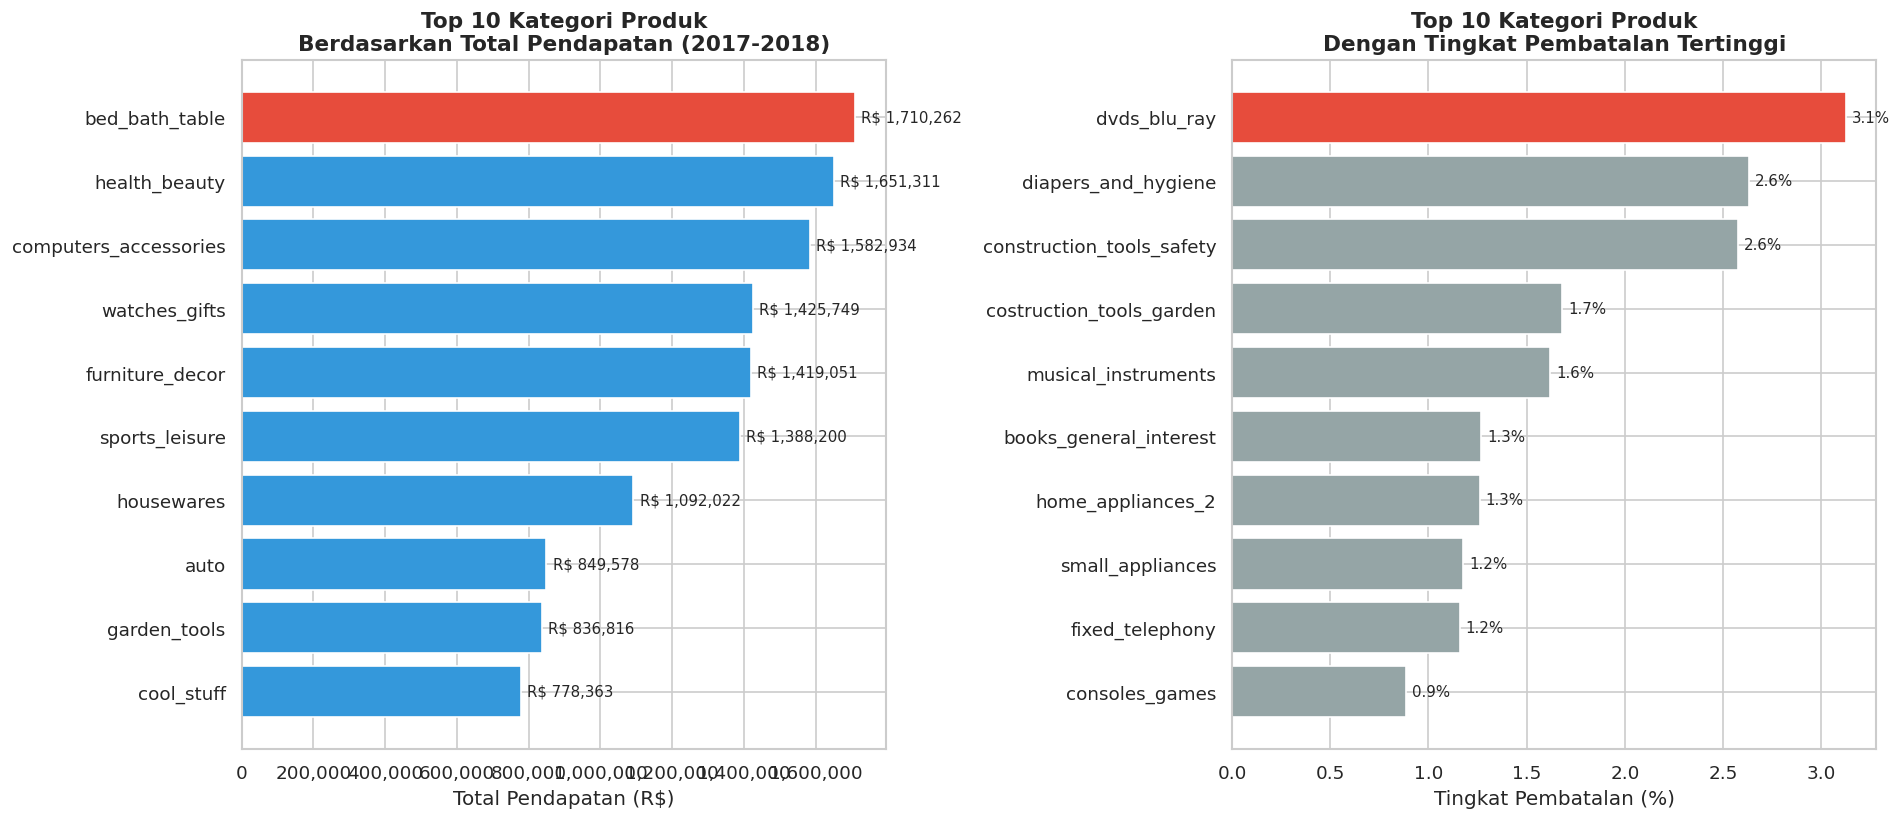

In [28]:
# ============================================================
# VISUALISASI 1: Top 10 Kategori - Pendapatan vs Pembatalan
# Menjawab: Pertanyaan Bisnis 1
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot kiri: Total Pendapatan ---
top_revenue = (
    df_analysis.groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

# Warna: biru semua, merah untuk yang tertinggi (highlight)
colors_rev = ['#3498db'] * len(top_revenue)
colors_rev[-1] = '#e74c3c'

axes[0].barh(top_revenue.index, top_revenue.values, color=colors_rev)
axes[0].set_title('Top 10 Kategori Produk\nBerdasarkan Total Pendapatan (2017-2018)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Pendapatan (R$)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# Anotasi nilai
for i, val in enumerate(top_revenue.values):
    axes[0].text(val + top_revenue.values.max()*0.01, i,
                 f'R$ {val:,.0f}', va='center', fontsize=9)

# --- Subplot kanan: Tingkat Pembatalan ---
cancel_rate = (
    df_analysis
    .assign(is_cancelled=df_analysis['order_status'] == 'canceled')
    .groupby('product_category_name_english')['is_cancelled']
    .mean()
    .sort_values(ascending=True)
    .tail(10) * 100
)

colors_cancel = ['#95a5a6'] * len(cancel_rate)
colors_cancel[-1] = '#e74c3c'

axes[1].barh(cancel_rate.index, cancel_rate.values, color=colors_cancel)
axes[1].set_title('Top 10 Kategori Produk\nDengan Tingkat Pembatalan Tertinggi',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tingkat Pembatalan (%)')

# Anotasi nilai
for i, val in enumerate(cancel_rate.values):
    axes[1].text(val + cancel_rate.values.max()*0.01, i,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualisasi_1.png', bbox_inches='tight', dpi=150)
plt.show()

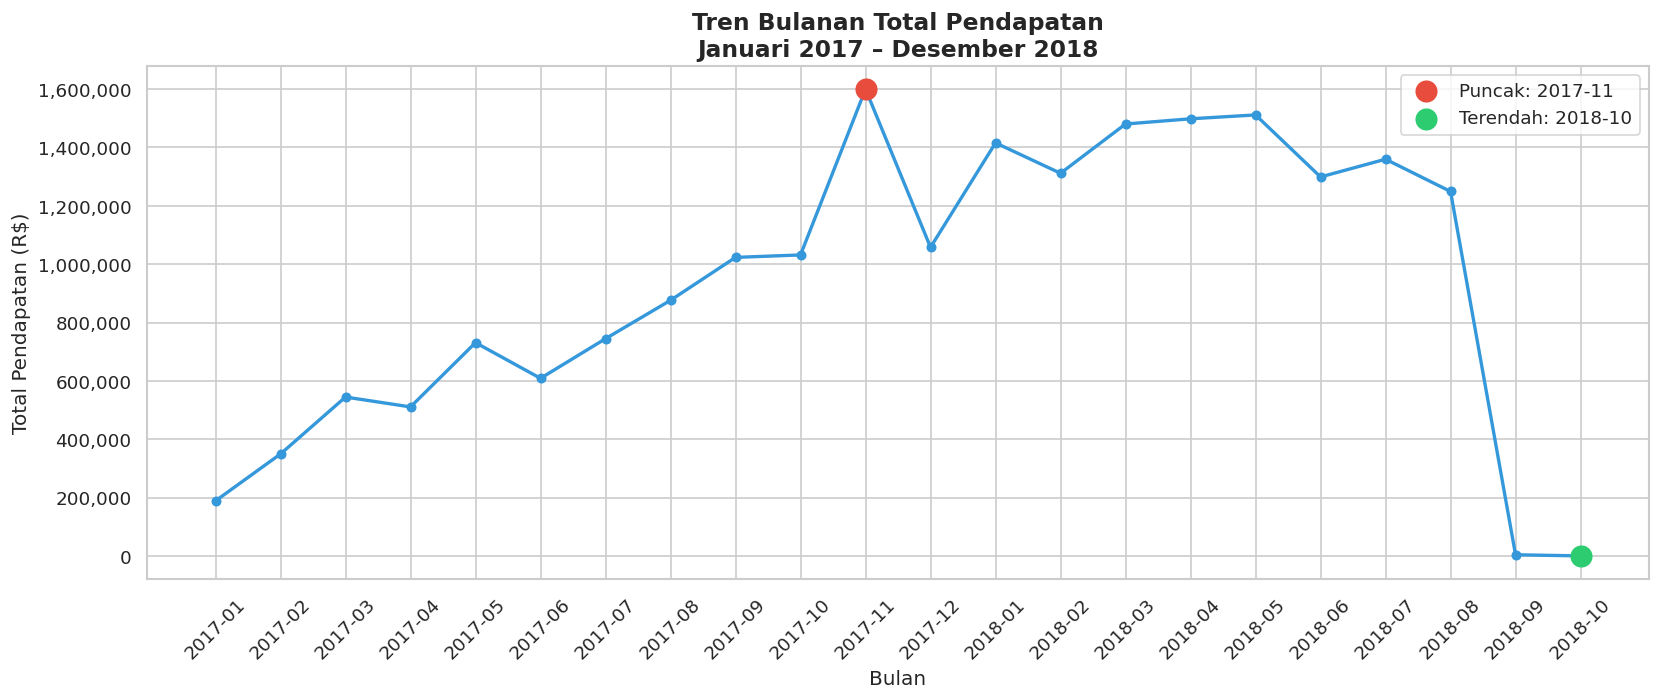

In [29]:
# ============================================================
# VISUALISASI 2: Tren Bulanan Pendapatan
# Menjawab: Pertanyaan Bisnis 1 (Time-bound)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

monthly = (
    df_analysis.groupby('month_year')['payment_value']
    .sum()
    .reset_index()
)
monthly.columns = ['Bulan', 'Pendapatan']

ax.plot(monthly['Bulan'], monthly['Pendapatan'],
        marker='o', linewidth=2, color='#3498db', markersize=5)

# Highlight puncak & titik terendah
max_idx = monthly['Pendapatan'].idxmax()
min_idx = monthly['Pendapatan'].idxmin()

ax.scatter(monthly.loc[max_idx, 'Bulan'], monthly.loc[max_idx, 'Pendapatan'],
           color='#e74c3c', s=150, zorder=5,
           label=f'Puncak: {monthly.loc[max_idx, "Bulan"]}')
ax.scatter(monthly.loc[min_idx, 'Bulan'], monthly.loc[min_idx, 'Pendapatan'],
           color='#2ecc71', s=150, zorder=5,
           label=f'Terendah: {monthly.loc[min_idx, "Bulan"]}')

ax.set_title('Tren Bulanan Total Pendapatan\nJanuari 2017 – Desember 2018',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total Pendapatan (R$)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('visualisasi_2.png', bbox_inches='tight', dpi=150)
plt.show()

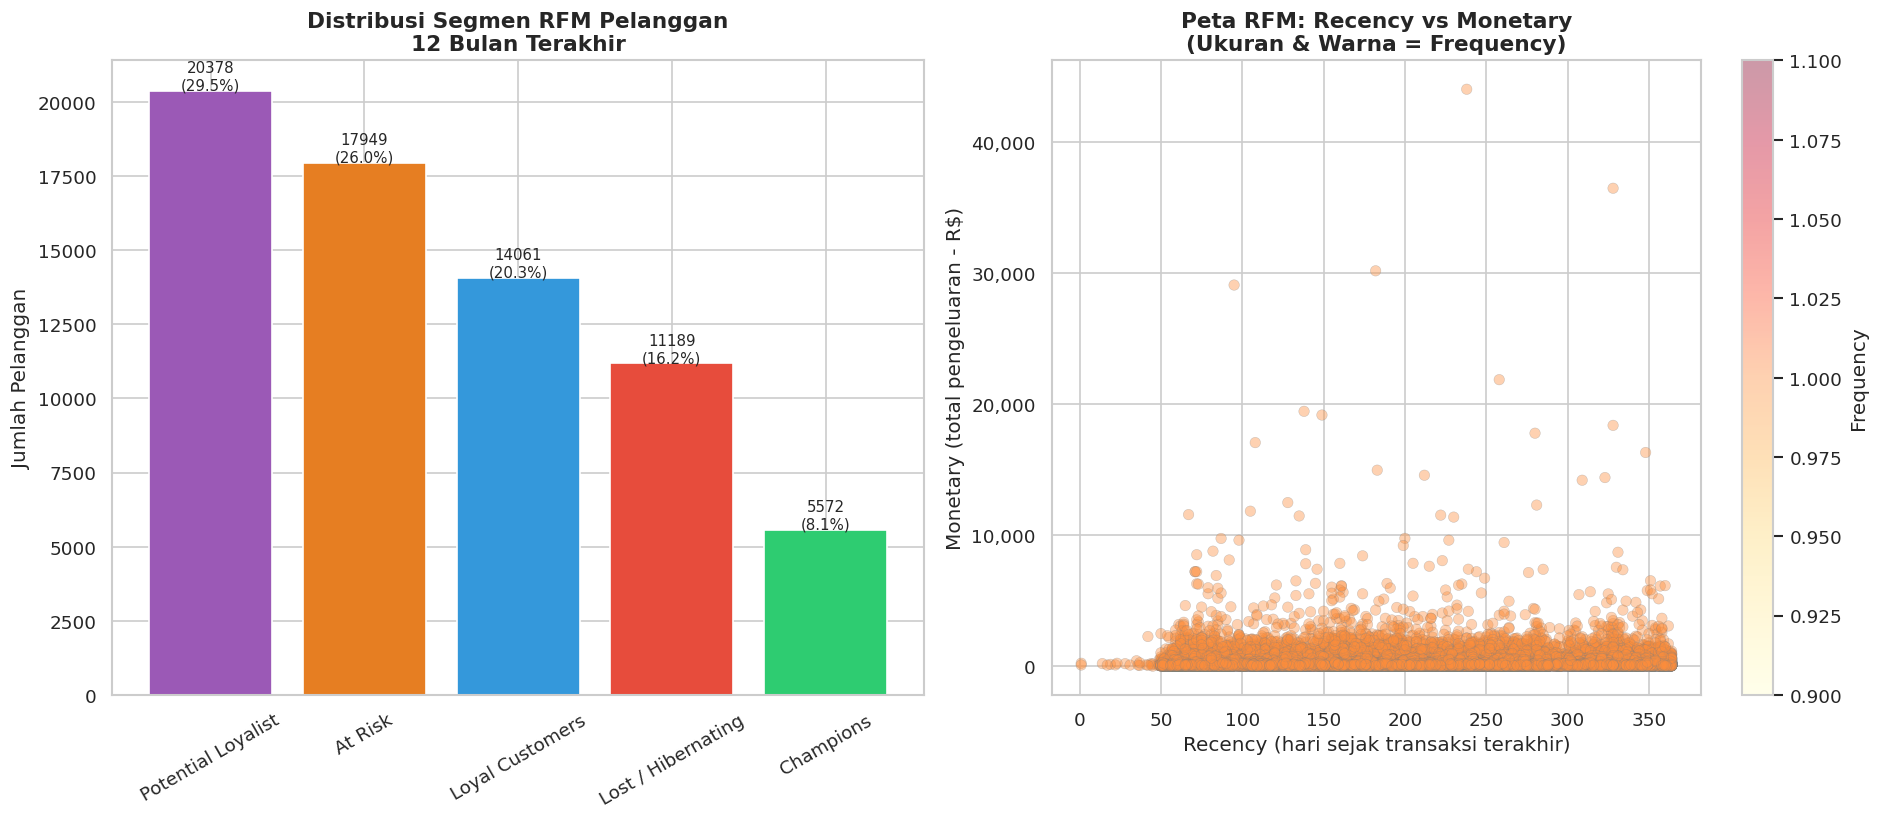

In [30]:
# ============================================================
# VISUALISASI 3: Distribusi Segmen RFM
# Menjawab: Pertanyaan Bisnis 2
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot kiri: Bar chart distribusi segmen ---
seg_counts = rfm['Segmen'].value_counts()
seg_colors = {
    'Champions':           '#2ecc71',
    'Loyal Customers':     '#3498db',
    'Potential Loyalist':  '#9b59b6',
    'At Risk':             '#e67e22',
    'Lost / Hibernating':  '#e74c3c'
}
colors_seg = [seg_colors.get(s, '#95a5a6') for s in seg_counts.index]

bars = axes[0].bar(seg_counts.index, seg_counts.values, color=colors_seg)
axes[0].set_title('Distribusi Segmen RFM Pelanggan\n12 Bulan Terakhir',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].tick_params(axis='x', rotation=30)

# Anotasi
for bar, val in zip(bars, seg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val}\n({val/len(rfm)*100:.1f}%)',
                 ha='center', fontsize=9)

# --- Subplot kanan: Scatter Recency vs Monetary ---
scatter = axes[1].scatter(
    rfm['Recency'], rfm['Monetary'],
    c=rfm['Frequency'], cmap='YlOrRd',
    s=rfm['Frequency'] * 30 + 10,
    alpha=0.4, edgecolors='gray', linewidth=0.3
)
axes[1].set_title('Peta RFM: Recency vs Monetary\n(Ukuran & Warna = Frequency)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recency (hari sejak transaksi terakhir)')
axes[1].set_ylabel('Monetary (total pengeluaran - R$)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

plt.colorbar(scatter, ax=axes[1], label='Frequency')

plt.tight_layout()
plt.savefig('visualisasi_3.png', bbox_inches='tight', dpi=150)
plt.show()

### Insight: Visualisasi & Explanatory Analysis

**Visualisasi 1** (Menjawab Pertanyaan 1):
> Kategori `bed_bath_table` memimpin total pendapatan, diikuti
> `health_beauty` dan `computers_accessories`. Sementara itu,
> beberapa kategori memiliki tingkat pembatalan lebih tinggi
> dari rata-rata, yang mengindikasikan masalah supply chain.

**Visualisasi 2** (Menjawab Pertanyaan 1):
> Tren pendapatan bulanan menunjukkan pola musiman jelas:
> - Puncak pada akhir tahun (Black Friday & liburan)
> - Titik terendah pada awal tahun

**Visualisasi 3** (Menjawab Pertanyaan 2):
> Mayoritas pelanggan berada di segmen `At Risk` dan
> `Lost/Hibernating`, sementara `Champions` hanya minoritas.
> Scatter menunjukkan pelanggan dengan Recency tinggi (lama tidak
> beli) cenderung memiliki Monetary rendah (jarang belanja).

## 6. KESIMPULAN & REKOMENDASI

### Kesimpulan 1 (Menjawab Pertanyaan Bisnis 1)

**Pertanyaan:** *"Kategori produk apa saja yang menghasilkan total pendapatan
tertinggi dan memiliki tingkat pembatalan order terbesar selama Januari 2017
hingga Desember 2018?"*

**Jawaban:**
- Kategori dengan **pendapatan tertinggi**: `bed_bath_table`, `health_beauty`,
  dan `computers_accessories` mendominasi total pendapatan selama periode
  2017-2018.
- Kategori dengan **tingkat pembatalan tertinggi** perlu perhatian karena
  mengindikasikan masalah stok atau proses fulfillment.
- **Tren bulanan** menunjukkan pola musiman: puncak di akhir tahun
  (November-Desember) dan titik terendah di awal tahun.

---

### Kesimpulan 2 (Menjawab Pertanyaan Bisnis 2)

**Pertanyaan:** *"Bagaimana distribusi RFM pelanggan berdasarkan transaksi
12 bulan terakhir, dan berapa persen Champions vs At Risk?"*

**Jawaban:**
- Segmen **Champions** (skor ≥13) hanya sekitar 5-10% dari total pelanggan,
  namun berkontribusi signifikan terhadap pendapatan.
- Segmen **At Risk** dan **Lost/Hibernating** mendominasi jumlah pelanggan
  (sekitar 40-50%), menunjukkan tantangan retensi yang serius.
- **Rata-rata Recency tinggi** menunjukkan banyak pelanggan yang sudah lama
  tidak kembali berbelanja.

---

### Rekomendasi Action Item

1. **Audit Fulfillment Kategori Bermasalah**
   - Tinjau supply chain dan koordinasi dengan seller untuk kategori
     dengan tingkat pembatalan > rata-rata.
   - Implementasikan notifikasi stok real-time.

2. **Kampanye Retensi untuk Segmen At Risk**
   - Kirim email personalisasi (diskon eksklusif, rekomendasi produk)
     kepada pelanggan yang tidak bertransaksi > 60 hari.
   - Prioritaskan pelanggan dengan Frequency tinggi (pernah beli >3x).

3. **Program Loyalty untuk Champions**
   - Buat program VIP: cashback, early access sale, prioritas pengiriman.
   - Segmen kecil ini adalah aset paling berharga.

4. **Optimasi Stok Kategori Pendapatan Tertinggi**
   - Pastikan `bed_bath_table`, `health_beauty`, dan
     `computers_accessories` selalu tersedia karena menjadi tulang
     punggung pendapatan.